# Introduction #

You'll build a model to predict hotel cancellations with a binary classifier.

In [12]:
# Setup plotting
# import matplotlib.pyplot as plt
# plt.style.use('seaborn-whitegrid')
# # Set Matplotlib defaults
# plt.rc('figure', autolayout=True)
# plt.rc('axes', labelweight='bold', labelsize='large',
#        titleweight='bold', titlesize=18, titlepad=10)
# plt.rc('animation', html='html5')



First, load the *Hotel Cancellations* dataset.

In [13]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

hotel = pd.read_csv('hotel.csv')

X = hotel.copy()
y = X.pop('is_canceled')

X['arrival_date_month'] = \
    X['arrival_date_month'].map(
        {'January':1, 'February': 2, 'March':3,
         'April':4, 'May':5, 'June':6, 'July':7,
         'August':8, 'September':9, 'October':10,
         'November':11, 'December':12}
    )

features_num = [
    "lead_time", "arrival_date_week_number",
    "arrival_date_day_of_month", "stays_in_weekend_nights",
    "stays_in_week_nights", "adults", "children", "babies",
    "is_repeated_guest", "previous_cancellations",
    "previous_bookings_not_canceled", "required_car_parking_spaces",
    "total_of_special_requests", "adr",
]
features_cat = [
    "hotel", "arrival_date_month", "meal",
    "market_segment", "distribution_channel",
    "reserved_room_type", "deposit_type", "customer_type",
]

transformer_num = make_pipeline(
    SimpleImputer(strategy="constant"), # there are a few missing values
    StandardScaler(),
)
transformer_cat = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="NA"),
    OneHotEncoder(handle_unknown='ignore'),
)

preprocessor = make_column_transformer(
    (transformer_num, features_num),
    (transformer_cat, features_cat),
)

# stratify - make sure classes are evenlly represented across splits
X_train, X_valid, y_train, y_valid = \
    train_test_split(X, y, stratify=y, train_size=0.75)

X_train = preprocessor.fit_transform(X_train)
X_valid = preprocessor.transform(X_valid)

input_shape = [X_train.shape[1]]

In [45]:
X[features_cat].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   hotel                 119390 non-null  object
 1   arrival_date_month    119390 non-null  int64 
 2   meal                  119390 non-null  object
 3   market_segment        119390 non-null  object
 4   distribution_channel  119390 non-null  object
 5   reserved_room_type    119390 non-null  object
 6   deposit_type          119390 non-null  object
 7   customer_type         119390 non-null  object
dtypes: int64(1), object(7)
memory usage: 7.3+ MB


In [41]:
X.shape

(119390, 31)

In [31]:
X[features_cat].nunique()
for col in features_cat[5:]:
    print(col, X[col].value_counts())

# X_train[features_cat]

reserved_room_type reserved_room_type
A    85994
D    19201
E     6535
F     2897
G     2094
B     1118
C      932
H      601
P       12
L        6
Name: count, dtype: int64
deposit_type deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64
customer_type customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64


# 1) Define Model #

The model we'll use this time will have both batch normalization and dropout layers. To ease reading we've broken the diagram into blocks, but you can define it layer by layer as usual.


Define a model with an architecture given by this diagram:

<figure style="padding: 1em;">
<img src="https://storage.googleapis.com/kaggle-media/learn/images/V04o59Z.png" width="400" alt="Diagram of network architecture: BatchNorm, Dense, BatchNorm, Dropout, Dense, BatchNorm, Dropout, Dense.">
<figcaption style="textalign: center; font-style: italic"><center>Diagram of a binary classifier.</center></figcaption>
</figure>


In [14]:
from tensorflow import keras
from tensorflow.keras import layers

# YOUR CODE HERE: define the model given in the diagram
model = keras.Sequential([
    layers.InputLayer(input_shape=input_shape),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid'),
])


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


# 2) Add Optimizer, Loss, and Metric #

Now compile the model with the Adam optimizer and binary versions of the cross-entropy loss and accuracy metric.

In [15]:
# YOUR CODE HERE
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)



Finally, run this cell to train the model and view the learning curves. It may run for around 60 to 70 epochs, which could take a minute or two.

Epoch 1/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7749 - loss: 0.4804 - val_accuracy: 0.7804 - val_loss: 0.4453
Epoch 2/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8030 - loss: 0.4203 - val_accuracy: 0.8038 - val_loss: 0.4073
Epoch 3/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8098 - loss: 0.4066 - val_accuracy: 0.8184 - val_loss: 0.3909
Epoch 4/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8139 - loss: 0.3975 - val_accuracy: 0.8180 - val_loss: 0.3859
Epoch 5/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8178 - loss: 0.3903 - val_accuracy: 0.8238 - val_loss: 0.3814
Epoch 6/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8200 - loss: 0.3852 - val_accuracy: 0.8237 - val_loss: 0.3798
Epoch 7/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8224 - loss: 0.3816 - val_accuracy: 0.8282 - val_loss: 0.3749
Epoch 8/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8242 - loss: 0.3782 - val_accu

<Axes: title={'center': 'Accuracy'}>

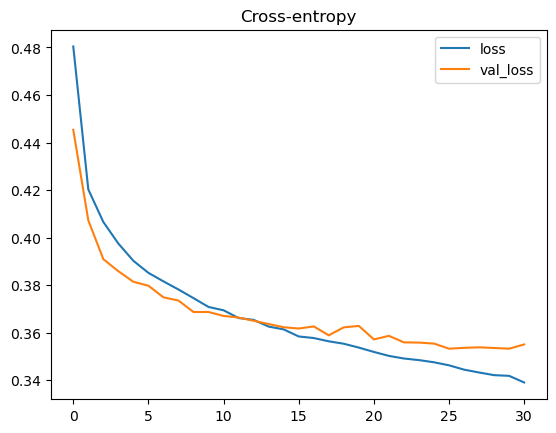

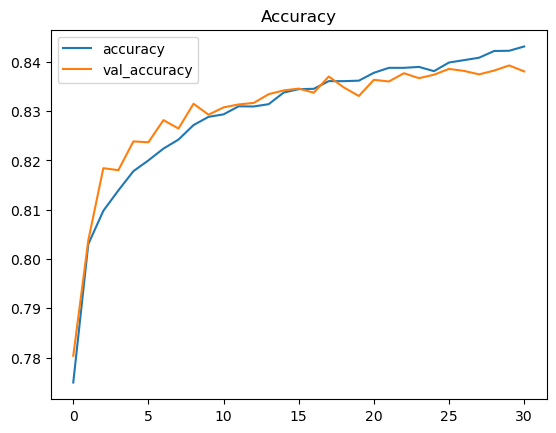

In [16]:
early_stopping = keras.callbacks.EarlyStopping(
    patience=5,
    min_delta=0.001,
    restore_best_weights=True,
)
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=512,
    epochs=200,
    callbacks=[early_stopping],
)

history_df = pd.DataFrame(history.history)
history_df
history_df.loc[:, ['loss', 'val_loss']].plot(title="Cross-entropy")
history_df.loc[:, ['accuracy', 'val_accuracy']].plot(title="Accuracy")

In [17]:
model.save("final_model.keras")
print("\nModel saved as final_model.keras")


Model saved as final_model.keras


# 3) Train and Evaluate #


What do you think about the learning curves? Does it look like the model underfit or overfit? Was the cross-entropy loss a good stand-in for accuracy?

Epoch 1/200


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


173/175 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7411 - auc: 0.7984 - loss: 0.5310
Epoch 1: val_loss improved from None to 0.45004, saving model to best_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7755 - auc: 0.8276 - loss: 0.4768 - val_accuracy: 0.8101 - val_auc: 0.8717 - val_loss: 0.4500 - learning_rate: 0.0010
Epoch 2/200
173/175 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8029 - auc: 0.8568 - loss: 0.4246
Epoch 2: val_loss improved from 0.45004 to 0.40028, saving model to best_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8053 - auc: 0.8599 - loss: 0.4199 - val_accuracy: 0.8160 - val_auc: 0.8780 - val_loss: 0.4003 - learning_rate: 0.0010
Epoch 3/200
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8102 - auc: 0.8677 - loss: 0.4087
Epoch 3: val_loss improved from 0.40028 to 0.38957, saving model to best_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8115 - auc: 0.8696 - loss: 0.4061 - val_accuracy: 0.818

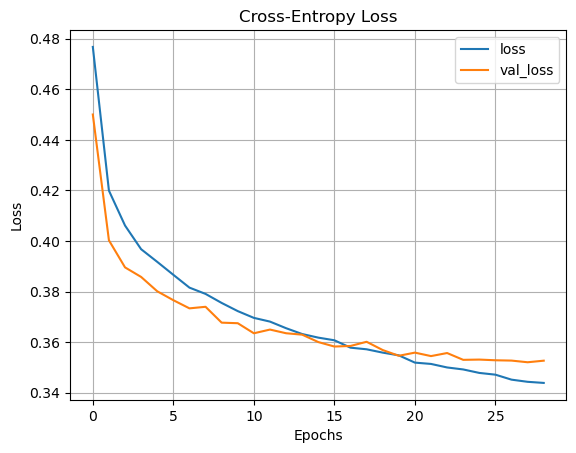

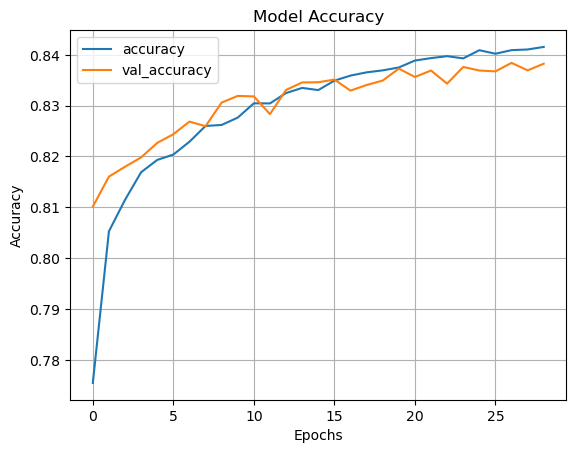


✅ Validation Accuracy: 0.8376
✅ Validation AUC: 0.9060
933/933 ━━━━━━━━━━━━━━━━━━━━ 1s 856us/step


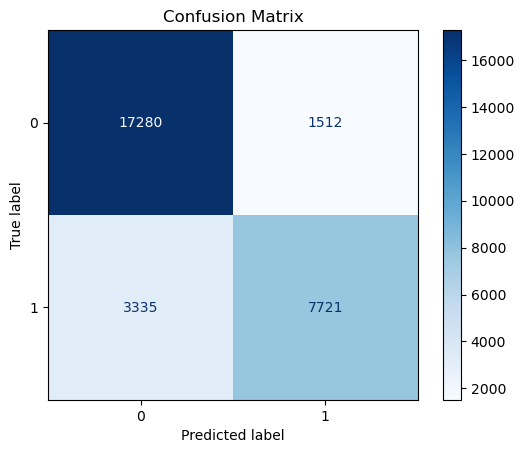

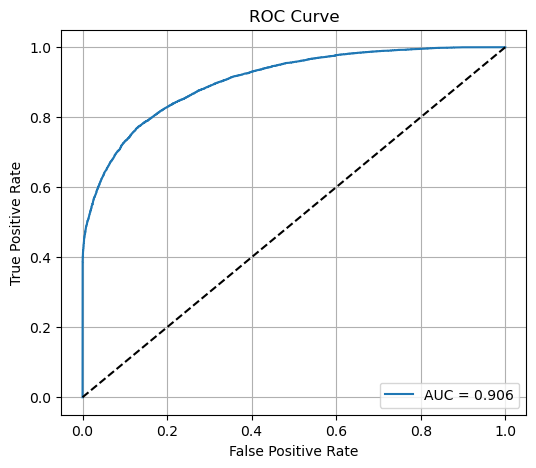


Model saved as final_model.keras


In [7]:
# ===============================
# 📦 Import Libraries
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

# ===============================
# 🧩 Define Model Architecture
# ===============================
input_shape = (X_train.shape[1],)   # ensure your X_train is defined

model = keras.Sequential([
    layers.InputLayer(input_shape=input_shape),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')
])

# ===============================
# ⚙️ Compile Model
# ===============================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

# ===============================
# 🛑 Early Stopping + LR Scheduler + Checkpoint
# ===============================
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

checkpoint = keras.callbacks.ModelCheckpoint(
    'best_model.keras',
    save_best_only=True,
    monitor='val_loss',
    mode='min',
    verbose=1
)

# ===============================
# 🚀 Train Model
# ===============================
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=512,
    epochs=200,
    callbacks=[early_stopping, lr_scheduler, checkpoint],
    verbose=1
)

# ===============================
# 📊 Plot Training History
# ===============================
history_df = pd.DataFrame(history.history)

# Loss Plot
ax = history_df[['loss', 'val_loss']].plot(title="Cross-Entropy Loss", grid=True)
ax.set_xlabel("Epochs")
ax.set_ylabel("Loss")

# Accuracy Plot
ax2 = history_df[['accuracy', 'val_accuracy']].plot(title="Model Accuracy", grid=True)
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")

plt.show()

# ===============================
# 🧾 Evaluate on Validation Set
# ===============================
val_results = model.evaluate(X_valid, y_valid, verbose=0)
print(f"\n✅ Validation Accuracy: {val_results[1]:.4f}")
print(f"✅ Validation AUC: {val_results[2]:.4f}")

# ===============================
# 🔍 Confusion Matrix
# ===============================
y_pred_prob = model.predict(X_valid)
y_pred = (y_pred_prob > 0.5).astype("int32")

cm = confusion_matrix(y_valid, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# ===============================
# 📈 ROC Curve
# ===============================
fpr, tpr, thresholds = roc_curve(y_valid, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# ===============================
# 💾 Save Final Model (Optional)
# ===============================

